In [1]:
import matplotlib.pyplot as plt
import torch
import traceback

from classifier import *
import os, random

from collections import Counter

In [2]:
print("cwd", os.getcwd())

cwd C:\Beryllium Base\WORKSPACES\MTECH\dl-vehicles\experiments


In [38]:
im_dataset = PipelinedDataset(IMDataset(hard_limit=1000, dtype=np.float32), simple_process_sample)
oi_dataset = PipelinedDataset(OIDv6Dataset(hard_limit=1000, dtype=np.float32), process_sample_v2)
al_dataset = AlternatingDataset(im_dataset, oi_dataset)
al_dataloader = DataLoader(al_dataset, batch_size=64)

In [4]:
freqs: dict[str, int] = {}
for x in im_dataset:
    freqs[idx_to_class[int(x[1][1])]] = freqs.get(idx_to_class[int(x[1][1])], 0) + 1
Counter(freqs)

Counter({'car': 250, 'truck': 250, 'motorcycle': 250, 'bus': 250})

In [5]:
freqs: dict[str, int] = {}
for x in oi_dataset:
    cls = "unknown" if x[1][0] == 0 else idx_to_class[int(x[1][1])]
    freqs[cls] = freqs.get(cls, 0) + 1
print(Counter(freqs))

Counter({'unknown': 290, 'truck': 191, 'car': 190, 'bus': 171, 'motorcycle': 158})


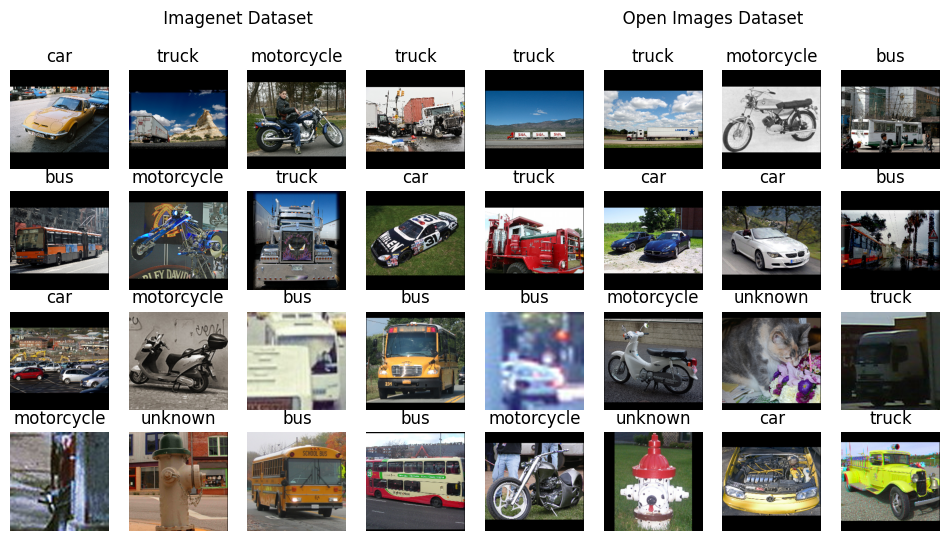

In [6]:
_, axs = plt.subplots(4, 8, figsize=(12, 6))
for ax, x in zip(axs.flatten()[:16], im_dataset):
    ax.imshow((255 * x[0].transpose(1, 2, 0)).astype(np.uint8))
    ax.set_title(idx_to_class[int(x[1][1])])
    ax.axis("off")
for ax, x in zip(axs.flatten()[16:], oi_dataset):
    ax.imshow((255 * x[0].transpose(1, 2, 0)).astype(np.uint8))
    ax.set_title("unknown" if x[1][0] == 0 else idx_to_class[int(x[1][1])])
    ax.axis("off")
plt.suptitle(f"{" " * 8} Imagenet Dataset {" " * 57} Open Images Dataset")
plt.show()

In [18]:
model = WhatAmIDoingCNN(out_classes=4)
print(model)

WhatAmIDoingCNN(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          )
          (2): Co

In [24]:
try:
    model.load_state_dict(torch.load('temp/model_state_space.pth'))
except:
    traceback.print_exc()

In [9]:
print(measure_size(model), "MB")

4.23612117767334 MB


In [19]:
cel = nn.CrossEntropyLoss()
bce = nn.BCEWithLogitsLoss()


class ContextfulLoss(nn.Module):
    def forward(self, logits, targets):
        p_cls, p_dis = logits

        t_dis = targets[:, 0].float()   # [B]
        t_cls = targets[:, 1]           # [B]

        # Discriminator loss
        dis_loss = bce(p_dis.squeeze(), t_dis)

        # Classification loss (masked for known samples)
        mask = t_dis == 1
        if mask.sum() > 0:
            cls_loss = cel(p_cls[mask], t_cls[mask])
        else:
            cls_loss = 0.0

        return dis_loss + cls_loss

In [20]:
al_trainer = Trainer(
    model=model,
    train_dataloader=al_dataloader,
    criterion=ContextfulLoss(),
    optimizer=lambda params: torch.optim.Adam(params, lr=0.003),
    epochs=10,
    checkpoint_frequency=5,
)

Epoch:  1/10    Train Loss: 0.21    TTS: 19.66    ETA: 176.93
Epoch:  2/10    Train Loss: 0.21    TTS: 38.50    ETA: 154.00
Epoch:  3/10    Train Loss: 0.18    TTS: 57.19    ETA: 133.44
Epoch:  4/10    Train Loss: 0.18    TTS: 75.96    ETA: 113.94
Epoch:  5/10    Train Loss: 0.19    TTS: 94.72    ETA: 94.72
Epoch:  6/10    Train Loss: 0.18    TTS: 113.47    ETA: 75.64
Epoch:  7/10    Train Loss: 0.19    TTS: 132.20    ETA: 56.66
Epoch:  8/10    Train Loss: 0.18    TTS: 150.88    ETA: 37.72
Epoch:  9/10    Train Loss: 0.18    TTS: 169.51    ETA: 18.83
Epoch: 10/10    Train Loss: 0.21    TTS: 188.19    ETA: 0.00


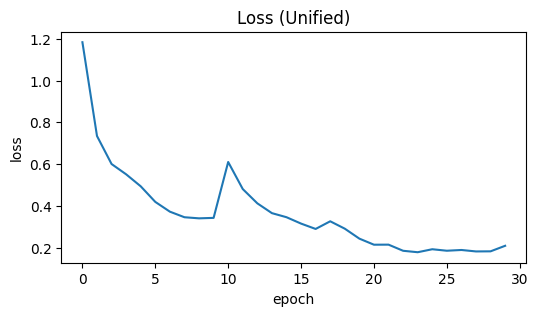

In [34]:
try:
    al_trainer.train()
    _, ax = plt.subplots(1, 1, figsize=(6, 3))
    ax.plot(al_trainer.loss["train"])
    ax.set_ylabel("loss"), ax.set_xlabel("epoch")
    plt.title("Loss (Unified)"), plt.show()
except:
    traceback.print_exc()

In [28]:
print(" Mixed")
print("Tt Load 1 Batch  : %6.2f sec" % tuple(x.timer.timers['train_dataloader'].average for x in [al_trainer]))
print("Tt Train 1 Batch : %6.2f sec" % tuple(x.timer.timers['batch'].average for x in [al_trainer]))
print("Tf 1 Full Step   : %6.2f sec" % tuple(x.timer.timers['_train_step'].average for x in [al_trainer]))
print("TT for Training  : %6.2f sec" % tuple(x.timer.timers['train'].average for x in [al_trainer]))

 Mixed
Tt Load 1 Batch  :   0.41 sec
Tt Train 1 Batch :   0.21 sec
Tf 1 Full Step   :  19.69 sec
TT for Training  : 196.94 sec


tensor([1, 2])
index 2
class car


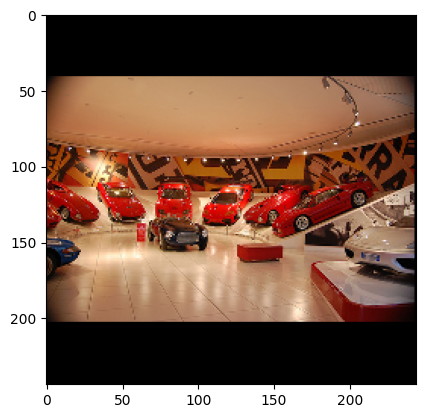

In [29]:
test_sample = None
# for sample in im_dataloader:
for sample in al_dataloader:
    test_sample = sample
    if random.randint(1, 10) == 1:
        break

idx = random.randint(0, len(test_sample[0]) - 1)
sample_i = (255 * test_sample[0][idx].detach().numpy().transpose(1, 2, 0)).astype(np.uint8)
print(test_sample[1][idx])
print("index", test_sample[1][idx][1].detach().item())
print("class", idx_to_class[int(test_sample[1][idx][1].detach().item())])

try:
    plt.imshow(sample_i)
except Exception as e:
    print(e)
    pass

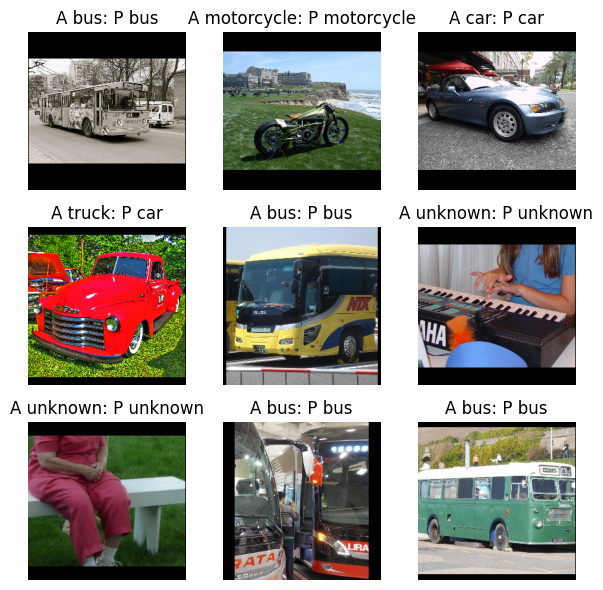

In [30]:
try:
    indices = list(range(len(test_sample[0])))
    random.shuffle(indices)
    indices = indices[:9]
    predictions = model(test_sample[0][indices])

    _, axs = plt.subplots(3, 3, figsize=(6, 6))
    for idx, ax, dis, cls in zip(indices, axs.flatten(), predictions[1], predictions[0]):
        ax.imshow((255 * test_sample[0][idx].detach().numpy().transpose(1, 2, 0)).astype(np.uint8))
        d, c = test_sample[1][idx].detach().numpy()
        a = "unknown" if d == 0 else idx_to_class[int(c)]
        d, c = dis.detach().item(), cls.argmax().detach().item()
        p = "unknown" if d < 0 else idx_to_class[int(c)]
        ax.set_title(f"A {a}: P {p}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
except:
    traceback.print_exc()

In [35]:
try:
    torch.save(model.state_dict(), fop('temp\\model_state_space.pth'))
except:
    traceback.print_exc()

In [36]:
try:
    def evaluate_accuracy(model, dataloader, device="cpu"):
        model.eval()

        total = 0
        correct = 0

        known_total = 0
        known_correct = 0

        unknown_total = 0
        unknown_correct = 0

        with torch.no_grad():
            for batch in dataloader:
                x, y = batch
                x = x.to(device)
                y = y.to(device)

                p_cls, p_dis = model(x)

                # --- Ground truth ---
                t_dis = y[:, 0]          # 0 or 1
                t_cls = y[:, 1]          # 0–3

                # --- Predictions ---
                pred_dis = (p_dis.squeeze() > 0).long()   # known vs unknown
                pred_cls = p_cls.argmax(dim=1)            # class prediction

                # Final prediction: 0–3 or 4
                final_pred = torch.where(
                    pred_dis == 1,
                    pred_cls,
                    torch.tensor(4, device=device)
                )

                # Ground truth final label
                final_true = torch.where(
                    t_dis == 1,
                    t_cls,
                    torch.tensor(4, device=device)
                )

                # --- Overall accuracy ---
                correct += (final_pred == final_true).sum().item()
                total += final_true.size(0)

                # --- Known accuracy ---
                known_mask = t_dis == 1
                if known_mask.sum() > 0:
                    known_correct += (pred_cls[known_mask] == t_cls[known_mask]).sum().item()
                    known_total += known_mask.sum().item()

                # --- Unknown accuracy ---
                unknown_mask = t_dis == 0
                if unknown_mask.sum() > 0:
                    unknown_correct += (pred_dis[unknown_mask] == 0).sum().item()
                    unknown_total += unknown_mask.sum().item()

        return {
            "overall_acc": correct / total if total > 0 else 0,
            "known_acc": known_correct / known_total if known_total > 0 else 0,
            "unknown_acc": unknown_correct / unknown_total if unknown_total > 0 else 0,
        }

    print(evaluate_accuracy(model, al_dataloader))
except:
    pass

{'overall_acc': 0.9215, 'known_acc': 0.9432748538011696, 'unknown_acc': 0.9413793103448276}


In [39]:
try:
    oi_dataloader = DataLoader(oi_dataset, batch_size=64)
    print(evaluate_accuracy(model, oi_dataloader))
except:
    traceback.print_exc()

{'overall_acc': 0.78, 'known_acc': 0.7641242937853108, 'unknown_acc': 0.9006849315068494}


In [41]:
try:
    oi_dataset_test = PipelinedDataset(OIDv6Dataset(hard_limit=1000, specimen='validation', dtype=np.float32), process_sample_v2)
    oi_dataloader = DataLoader(oi_dataset_test, batch_size=64)
    print(evaluate_accuracy(model, oi_dataloader))
except:
    traceback.print_exc()

{'overall_acc': 0.801, 'known_acc': 0.8023426061493412, 'unknown_acc': 0.8643533123028391}
